In [1]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

ModuleNotFoundError: No module named 'scipy'

# Homework 2

#### Authors: Agata Mozwilo & Ólafur Fortune


## Exersice 23 
A simple model for the stock market suggests that each day a stock with price $q$ will increase by a factor $r > 1$ to $qr$ with probability $p$ and will fall to $q/r$ with probability $1 − p$. Assume that we start with a stock with price 1. Find a formula for the expected value and the variance of the price of the stock after $d$ days

### Answer
* $E[q_d]=\left(pr+\frac{1-p}{r}\right)^d$
* $\text{Var}(q_d)=\left(pr^2+\frac{1-p}{r^2}\right)^d-\left(pr+\frac{1-p}{r}\right)^{2d}$

### Solution
Let $X_i$ be the factor by which the stock price changes on day $i$, such that
$$
X_i=\begin{cases}
r, & \text{wp }p \\
1/r, & \text{wp }1-p
\end{cases}
$$
With expected value
$$
E[X_i]=pr+\frac{1-p}{r}
$$
After $d$ days, the stock price $q$ on day $d$ will be:
$$
q_d=\prod_{i=0}^d X_i=q_0\prod_{i=1}^d X_i
$$
The expected value of the stock price is:
$$
E[q_d]=E\left[q_0\prod_{i=1}^d X_i\right]
$$
Note that $q_0=1$. Due to each $X_i$ being independent, the expected value of the products is the product of the expected values:
$$
E[q_d]=\prod_{i=1}^d E\left[X_i\right]=E[X_1]E[X_2]\cdots E[X_d]=\left(pr+\frac{1-p}{r}\right)^d
$$
For the variance, we use the formula
$$
\text{Var}(q_d)=E[q_d^2]-(E[q_d])^2
$$
We can use the same formula for $q_d$ to obtain
$$
q_d^2=\left(q_0\prod_{i=1}^d X_i\right)^2=q_0\prod_{i=1}^d X_i^2
$$
We can define:
$$
X_i^2=\begin{cases}
r^2, & \text{wp }p \\
1/r^2, & \text{wp }1-p
\end{cases}
$$
We then have
$$
E[X_i^2]=pr^2+\frac{1-p}{r^2}
$$
Using the independence of $X_i$ again we get:
$$
E[q_d^2]=\left(pr^2+\frac{1-p}{r^2}\right)^2
$$
So
$$
\text{Var}(q_d)=\left(pr^2+\frac{1-p}{r^2}\right)^d-\left(pr+\frac{1-p}{r}\right)^{2d}
$$
### Python
Let $r = 1.1$, $p = 0.5$, and $q = 1$. Simulate 200 stocks over 50
days. Estimate the expected value and the variance of the price of the stock for
$0 ≤ d ≤ 50$ and compare with your theoretical results. Plot your results.

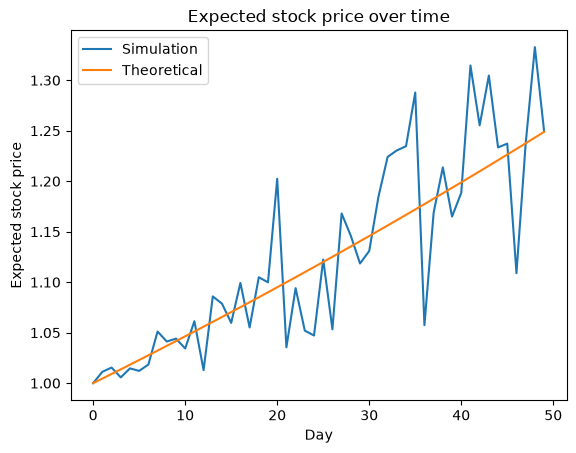

In [25]:
r=1.1
p=0.5
q=1
n=200
d=50

mean_results = np.zeros(d)
var_results = np.zeros(d)

def X(p,r):
    if np.random.random() < p:
        return r
    else:
        return 1/r

def X2(p,r):
    if np.random.random() < p:
        return r**2        
    else:
        return 1/(r**2)

def stock_price(p, r, d):
    q = 1
    for _ in range(d):
        q *= X(p,r)
    return q

for i in range(d):
    simulations = np.zeros(n)
    for j in range(n):
        simulations[j] = stock_price(p, r, i)
    mean_results[i] = np.mean(simulations)
    var_results[i]= np.var(simulations)

days = np.arange(d)
theoretical_mean = (p*r + (1-p)/r)**days
theoretical_var = (p*r**2+(1-p)/r**2)**days - (p*r+(1-p)/r)**(2*days)


plt.plot(days, mean_results, label="Simulation")
plt.plot(days, theoretical_mean, label="Theoretical")
plt.xlabel("Day")
plt.ylabel("Expected stock price")
plt.title("Expected stock price over time")
plt.legend()

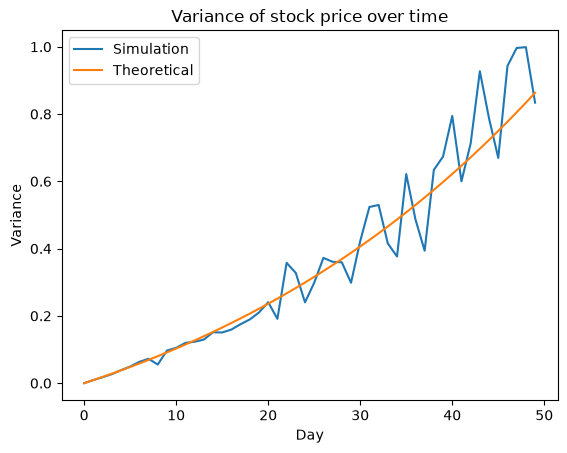

In [24]:
days = np.arange(d)
theoretical = (p*r + (1-p)/r)**days

plt.plot(days, var_results, label="Simulation")
plt.plot(days, theoretical_var, label="Theoretical")
plt.xlabel("Day")
plt.ylabel("Variance")
plt.title("Variance of stock price over time")
plt.legend()

## Exersice 28
We have a standard six-sided die. Let X be the number of times that a 6 occurs over $n$ throws of the die. Let $p$ the probability of the event $X ≥ n/4$. Compare the best upper bounds on $p$ that you can obtain using Markov’s inequality Chebyshev’s inequality, and Chernoff bounds.

### Answer
*

### Solution
Let's define:
$$
X_i =
\begin{cases}
1, & \text{if throw } i \text{ is a 6},\\
0, & \text{otherwise}
\end{cases}
$$

Since the probability of rolling a 6 on a standard die is

$$
P(X_i=1)=\frac{1}{6}
$$

each $X_i$ is a Bernoulli random variable with probability of $1/6$. The number of sixes obtained in $n$ independent throws is

$$
X=\sum_{i=1}^{n}X_i
$$

so,
$$
X\sim\mathrm{Bin}\left(n,\frac{1}{6}\right)
$$

The event stated in the problem is

$$
\left\{X\geq\frac{n}{4}\right\}
$$

Since $X$ can only take integer values, we rewrite the expression as:

$$
\left\{X\geq\frac{n}{4}\right\}
=
\{X\geq k\},
\qquad
k=\left\lceil\frac{n}{4}\right\rceil
$$

LEts first use the threshold $n/4$ directly.

The expected value of $X$ is

$$
\begin{aligned}
\mathbb{E}[X]
&=
\mathbb{E}\left[\sum_{i=1}^{n}X_i\right]\\
&=
\sum_{i=1}^{n}\mathbb{E}[X_i]\\
&=
\sum_{i=1}^{n}\frac{1}{6}\\
&=
\frac{n}{6}
\end{aligned}
$$

Markov's inequality states that for a non negative random variable $X$ and $a>0$:

$$
P(X\geq a)\leq\frac{\mathbb{E}[X]}{a}
$$

Since $X$ is a number of sixes, $X\geq0$, it satisfies our condition and therefore we can use Markov's inequality: 

$$
a=\frac{n}{4},
$$

we get

$$
\begin{aligned}
P\left(X\geq\frac{n}{4}\right)
&\leq
\frac{\mathbb{E}[X]}{n/4}\\
&=
\frac{n/6}{n/4}\\
&=
\frac{n}{6}\frac{4}{n}\\
&=
\frac{4}{6}\\
&=
\frac{2}{3}
\end{aligned}
$$

So, the Markov bound is

$$

P\left(X\geq\frac{n}{4}\right)\leq\frac{2}{3}

$$

If the integer threshold $k=\lceil n/4\rceil$ is used instead, the Markov bound is

$$P(X\geq k)\leq\frac{n}{6k}$$

Which is a bit tighter than the one we did before. 


For Chebyshev's inequality, we also need the variance of $X$. Since $X$ is binomial,

$$
\operatorname{Var}(X)
=
np(1-p).
$$

Here $p=1/6$, so

$$
\begin{aligned}
\operatorname{Var}(X)
&=
n\left(\frac{1}{6}\right)
\left(1-\frac{1}{6}\right)\\
&=
n\left(\frac{1}{6}\right)
\left(\frac{5}{6}\right)\\
&=
\frac{5n}{36}
\end{aligned}
$$

Chebyshev's inequality states that

$$
P\left(|X-\mathbb{E}[X]|\geq a\right)
\leq
\frac{\operatorname{Var}(X)}{a^2}
$$

Our event is

$$
P\left(X\geq\frac{n}{4}\right)
$$

Since

$$
\mathbb{E}[X]=\frac{n}{6}
$$

we can subtract the mean from both sides of the inequality inside the event:

$$
\begin{aligned}
X
&\geq
\frac{n}{4}\\
X-\frac{n}{6}
&\geq
\frac{n}{4}-\frac{n}{6}
\end{aligned}
$$

Using a common denominator,

$$
\frac{n}{4}-\frac{n}{6}
=
\frac{3n}{12}-\frac{2n}{12}
=
\frac{n}{12}.
$$

So,

$$
P\left(X\geq\frac{n}{4}\right)
=
P\left(
X-\frac{n}{6}\geq\frac{n}{12}
\right)
$$

If

$$
X-\frac{n}{6}\geq\frac{n}{12}
$$

then necessarily

$$
\left|X-\frac{n}{6}\right|
\geq
\frac{n}{12}
$$

Therefore,

$$
P\left(
X-\frac{n}{6}\geq\frac{n}{12}
\right)
\leq
P\left(
\left|X-\frac{n}{6}\right|
\geq
\frac{n}{12}
\right)
$$

Applying Chebyshev's inequality gives

$$
\begin{aligned}
P\left(X\geq\frac{n}{4}\right)
&\leq
P\left(
\left|X-\frac{n}{6}\right|
\geq
\frac{n}{12}
\right)\\
&\leq
\frac{\operatorname{Var}(X)}
{\left(n/12\right)^2}\\
&=
\frac{5n/36}
{\left(n/12\right)^2}
\end{aligned}
$$

Now,

$$
\left(\frac{n}{12}\right)^2
=
\frac{n^2}{144}
$$

so

$$
\begin{aligned}
P\left(X\geq\frac{n}{4}\right)
&\leq
\frac{5n/36}{n^2/144}\\
&=
\frac{5n}{36}\frac{144}{n^2}\\
&=
\frac{5n\cdot4}{n^2}\\
&=
\frac{20n}{n^2}\\
&=
\frac{20}{n}
\end{aligned}
$$

So, the Chebyshev bound is

$$

P\left(X\geq\frac{n}{4}\right)
\leq
\frac{20}{n}

$$

For the Chernoff bound, we use the moment-generating function. For any $t>0$,

$$
P(X\geq a)
=
P(e^{tX}\geq e^{ta})
$$

Since $e^{tX}$ is nonnegative, Markov's inequality gives

$$
P(e^{tX}\geq e^{ta})
\leq
\frac{\mathbb{E}[e^{tX}]}{e^{ta}}
$$

Therefore,

$$
P(X\geq a)
\leq
e^{-ta}\mathbb{E}[e^{tX}]
$$

For one Bernoulli random variable $X_i$,

$$
\begin{aligned}
M_{X_i}(t)
&=
\mathbb{E}[e^{tX_i}]\\
&=
P(X_i=0)e^0
+
P(X_i=1)e^t\\
&=
\frac{5}{6}
+
\frac{1}{6}e^t\\
&=
\frac{5+e^t}{6}
\end{aligned}
$$

Since

$$
X=X_1+\cdots+X_n
$$

and the $X_i$ are independent,

$$
\begin{aligned}
M_X(t)
&=
\mathbb{E}\left[
e^{t(X_1+\cdots+X_n)}
\right]\\
&=
\mathbb{E}\left[
e^{tX_1}\cdots e^{tX_n}
\right]\\
&=
\prod_{i=1}^{n}
\mathbb{E}[e^{tX_i}]\\
&=
\left(
\frac{5+e^t}{6}
\right)^n
\end{aligned}
$$

Using

$$
a=\frac{n}{4}
$$

the Chernoff bound becomes

$$
P\left(X\geq\frac{n}{4}\right)
\leq
e^{-tn/4}
\left(
\frac{5+e^t}{6}
\right)^n
$$

We want the best possible Chernoff bound, so we minimize the right-hand side over $t>0$. Taking the natural logarithm gives

$$
f(t)
=
n\ln\left(\frac{5+e^t}{6}\right)
-
\frac{tn}{4}.
$$

Differentiating,

$$

f'(t)
&=
n\frac{e^t}{5+e^t}
-
\frac{n}{4}

$$

Set the derivative equal to zero:

$$
n\frac{e^t}{5+e^t}
-
\frac{n}{4}
=
0.
$$

Divide by $n$:

$$
\frac{e^t}{5+e^t}
=
\frac{1}{4}
$$

Multiply both sides by $4(5+e^t)$:

$$
4e^t
=
5+e^t.
$$

Therefore,

$$
3e^t=5
$$

and hence

$$
e^t=\frac{5}{3}.
$$


$$
t^*=\ln\left(\frac{5}{3}\right)
$$

Substituting this value into the Chernoff bound gives

$$
P\left(X\geq\frac{n}{4}\right)
\leq
e^{-\frac{n}{4}\ln(5/3)}
\left(
\frac{5+5/3}{6}
\right)^n
$$

We can simplify: 

$$
\begin{aligned}
\frac{5+5/3}{6}
&=
\frac{15/3+5/3}{6}\\
&=
\frac{20/3}{6}\\
&=
\frac{20}{18}\\
&=
\frac{10}{9}
\end{aligned}
$$

Also,

$$
e^{-\frac{n}{4}\ln(5/3)}
=
\left(\frac{5}{3}\right)^{-n/4}
=
\left(\frac{3}{5}\right)^{n/4}
$$

Therefore,

$$
\begin{aligned}
P\left(X\geq\frac{n}{4}\right)
&\leq
\left(\frac{3}{5}\right)^{n/4}
\left(\frac{10}{9}\right)^n\\
&=
\left[
\frac{10}{9}
\left(\frac{3}{5}\right)^{1/4}
\right]^n.
\end{aligned}
$$

So, the optimized Chernoff bound is

$$

P\left(X\geq\frac{n}{4}\right)
\leq
\left[
\frac{10}{9}
\left(\frac{3}{5}\right)^{1/4}
\right]^n

$$

Since $X\sim\mathrm{Bin}(n,1/6)$, the actual probability can be calculated exactly from the binomial probability mass function. The event requires at least $k=\left\lceil\frac{n}{4}\right\rceil$ sixes, so
$$ P\left(X\geq\frac{n}{4}\right) = \sum_{j=\lceil n/4\rceil}^{n} \binom{n}{j} \left(\frac{1}{6}\right)^j \left(\frac{5}{6}\right)^{n-j}$$

The Markov bound is approximately constant at $2/3$, so it is very loose. The Chebyshev bound decreases as $20/n$, which improves as $n$ increases. The Chernoff bound decreases exponentially with $n$ and therefore gives the best upper bound of the three for the values of $n$ considered in this problem. The simulated probability should fluctuate around the exact binomial probability. Since only $1000$ simulations are performed for each value of $n$, the simulation becomes less accurate when the event becomes very rare.



### Python
Simulate the dice throws for $10^2 ≤ n ≤ 150$ over $1000$ instances
and estimate $p$ for the different values of $n$. Calculate the actual value of $p$.
Compare the simulations and the bounds with the actual value of $p$. Plot your
results. Which gives a better approximation for p for different values of $n$?
